# MMM Stress Test 04 — Endogeneity

**Question:** What happens when marketers increase this week's budget because last week's sales were already above plan?

**Stress variable:** Reactive-budgeting strength gamma (0.0 → 0.8)  
**Key result:** As gamma rises, Meta ROAS is upward biased — persistent demand lifts sales, sales trigger more Meta spend, and the model credits Meta for part of the continuing demand.  
Search and TV are barely affected because only Meta spend follows prior sales in this DGP.

---
Self-contained: numpy, pandas, matplotlib, statsmodels only.

## Section 1 — Configuration

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# ── True parameters ──────────────────────────────────────────────────────────
TRUE_ROAS = {'meta': 2.0, 'search': 5.0, 'tv': 1.5}
N_WEEKS   = 156
NOISE_SD  = 60_000
DEMAND_PERSISTENCE = 0.80  # last week's demand shock carries into this week
SALES_RESPONSE     = 0.10  # spend added per £1 of prior sales surprise at gamma=1

# ── Stress levels ─────────────────────────────────────────────────────────────
GAMMA_LEVELS = [0.0, 0.2, 0.4, 0.6, 0.8]

# ── Monte Carlo sizes ─────────────────────────────────────────────────────────
N_BASELINE = 500   # clean-case simulations
N_STRESS   = 300   # simulations per gamma level

MASTER_SEED = 20260831

print('Configuration loaded.')
print(f'TRUE_ROAS : {TRUE_ROAS}')
print(f'GAMMA_LEVELS : {GAMMA_LEVELS}')
print(f'N_WEEKS={N_WEEKS}  NOISE_SD={NOISE_SD:,}')
print(f'DEMAND_PERSISTENCE={DEMAND_PERSISTENCE}  SALES_RESPONSE={SALES_RESPONSE}')

Configuration loaded.
TRUE_ROAS : {'meta': 2.0, 'search': 5.0, 'tv': 1.5}
GAMMA_LEVELS : [0.0, 0.2, 0.4, 0.6, 0.8]
N_WEEKS=156  NOISE_SD=60,000
DEMAND_PERSISTENCE=0.8  SALES_RESPONSE=0.1


## Section 2 — Data-Generating Process

In [14]:
def generate_data(gamma: float, seed: int, n_weeks: int = N_WEEKS, noise_sd: float = NOISE_SD) -> tuple:
    """
    Generate synthetic MMM data with reactive-budgeting endogeneity.

    gamma = 0  →  Meta spend is independent of prior sales (clean case)
    gamma > 0  →  Meta spend rises after sales beat plan in the prior week

    The MMM does NOT observe latent_demand or the budgeting rule — only trend,
    seasonality, and promo. True causal Meta ROAS stays 2.0 for every gamma.

    Returns
    -------
    df    : pd.DataFrame with media, revenue, controls, and lagged-sales
            diagnostic columns
    truth : dict — true incremental revenue and diagnostic quantities
    """
    rng = np.random.default_rng(seed)
    t = np.arange(n_weeks)

    # ── Persistent latent demand (unobserved by MMM) ─────────────────────────
    # Persistence is essential: last week's high sales must predict some of
    # this week's baseline sales for reactive budgeting to bias the MMM.
    innovations = rng.normal(0, 200_000, n_weeks)
    latent_demand = np.zeros(n_weeks)
    latent_demand[0] = innovations[0] / np.sqrt(1 - DEMAND_PERSISTENCE**2)
    for week in range(1, n_weeks):
        latent_demand[week] = (
            DEMAND_PERSISTENCE * latent_demand[week - 1] + innovations[week]
        )

    # ── Promotions and exogenous media ──────────────────────────────────────
    promo = rng.binomial(1, 0.10, n_weeks).astype(float)
    search = np.clip(42_000 + 16_000 * rng.standard_normal(n_weeks), 5_000, None)
    tv = np.clip(90_000 + 45_000 * rng.standard_normal(n_weeks), 5_000, None)
    meta_noise = 22_000 * rng.standard_normal(n_weeks)
    revenue_noise = rng.normal(0, noise_sd, n_weeks)

    # ── Baseline revenue ─────────────────────────────────────────────────────
    baseline = (
        2_000_000
        + 4_000 * t
        + 500_000 * np.sin(2 * np.pi * t / 52)
        + 150_000 * np.cos(2 * np.pi * t / 52)
        + 0.3 * latent_demand
        + 400_000 * promo
    )

    # Expected revenue under average media and no latent demand shock.
    # The planner responds to last week's actual sales minus this plan.
    expected_revenue = (
        2_000_000
        + 4_000 * t
        + 500_000 * np.sin(2 * np.pi * t / 52)
        + 150_000 * np.cos(2 * np.pi * t / 52)
        + 400_000 * promo
        + TRUE_ROAS['meta'] * 55_000
        + TRUE_ROAS['search'] * 42_000
        + TRUE_ROAS['tv'] * 90_000
    )

    # ── Reactive Meta budgeting and realised revenue ────────────────────────
    # Current spend uses only information available at the end of the previous
    # week, so the simulation contains no look-ahead leakage.
    meta = np.empty(n_weeks)
    revenue = np.empty(n_weeks)
    lagged_sales_surprise = np.zeros(n_weeks)

    for week in range(n_weeks):
        if week > 0:
            lagged_sales_surprise[week] = (
                revenue[week - 1] - expected_revenue[week - 1]
            )

        meta_raw = (
            55_000
            + gamma * SALES_RESPONSE * lagged_sales_surprise[week]
            + meta_noise[week]
        )
        meta[week] = np.clip(meta_raw, 5_000, None)

        revenue[week] = (
            baseline[week]
            + TRUE_ROAS['meta'] * meta[week]
            + TRUE_ROAS['search'] * search[week]
            + TRUE_ROAS['tv'] * tv[week]
            + revenue_noise[week]
        )

    # ── Ground truth and diagnostics ─────────────────────────────────────────
    truth = {
        'meta_inc_revenue': TRUE_ROAS['meta'] * meta.sum(),
        'search_inc_revenue': TRUE_ROAS['search'] * search.sum(),
        'tv_inc_revenue': TRUE_ROAS['tv'] * tv.sum(),
        'meta_roas': TRUE_ROAS['meta'],
        'search_roas': TRUE_ROAS['search'],
        'tv_roas': TRUE_ROAS['tv'],
        'meta_spend_mean': meta.mean(),
        'search_spend_mean': search.mean(),
        'tv_spend_mean': tv.mean(),
        'meta_lagged_sales_corr': float(np.corrcoef(
            meta[1:], lagged_sales_surprise[1:]
        )[0, 1]),
        'meta_latent_corr': float(np.corrcoef(meta, latent_demand)[0, 1]),
    }

    df = pd.DataFrame({
        'week': t,
        'meta': meta,
        'search': search,
        'tv': tv,
        'revenue': revenue,
        'trend': t,
        'sin52': np.sin(2 * np.pi * t / 52),
        'cos52': np.cos(2 * np.pi * t / 52),
        'promo': promo,
        'sales_lag1': np.r_[np.nan, revenue[:-1]],
        'sales_surprise_lag1': np.r_[np.nan, lagged_sales_surprise[1:]],
    })

    return df, truth

print('generate_data() defined.')

generate_data() defined.


## Section 3 — Inspect One Dataset

In [15]:
# Inspect clean case (gamma=0) and a stressed case (gamma=0.6)
df0, truth0 = generate_data(gamma=0.0, seed=MASTER_SEED)
df6, truth6 = generate_data(gamma=0.6, seed=MASTER_SEED)

print('=== CLEAN CASE (gamma=0.0) ===')
print(f"  Meta   spend mean: £{truth0['meta_spend_mean']:>10,.0f}")
print(f"  Search spend mean: £{truth0['search_spend_mean']:>10,.0f}")
print(f"  TV     spend mean: £{truth0['tv_spend_mean']:>10,.0f}")
print(f"  Meta ↔ prior sales surprise corr: {truth0['meta_lagged_sales_corr']:.3f}")
print()
print('=== REACTIVE-BUDGET CASE (gamma=0.6) ===')
print(f"  Meta   spend mean: £{truth6['meta_spend_mean']:>10,.0f}")
print(f"  Meta ↔ prior sales surprise corr: {truth6['meta_lagged_sales_corr']:.3f}")
print(f"  Meta ↔ current latent demand corr: {truth6['meta_latent_corr']:.3f}")
print()

# Truth table
truth_rows = []
for ch in ['meta', 'search', 'tv']:
    truth_rows.append({
        'channel': ch,
        'true_roas': TRUE_ROAS[ch],
        'true_inc_rev': truth0[f'{ch}_inc_revenue'],
        'spend_mean': truth0[f'{ch}_spend_mean'],
    })
truth_df = pd.DataFrame(truth_rows)
print('Truth table (gamma=0):')
display(truth_df.round({'true_roas': 2, 'true_inc_rev': 0, 'spend_mean': 0}))

# Ground-truth consistency check
for ch in ['meta', 'search', 'tv']:
    computed = truth0[f'{ch}_inc_revenue'] / (truth0[f'{ch}_spend_mean'] * N_WEEKS)
    expected = TRUE_ROAS[ch]
    assert abs(computed - expected) < 0.01, f'{ch} ROAS check failed: {computed:.3f} != {expected}'
print('All ground-truth consistency checks PASSED.')

=== CLEAN CASE (gamma=0.0) ===
  Meta   spend mean: £    57,328
  Search spend mean: £    42,266
  TV     spend mean: £    91,518
  Meta ↔ prior sales surprise corr: 0.046

=== REACTIVE-BUDGET CASE (gamma=0.6) ===
  Meta   spend mean: £    57,184
  Meta ↔ prior sales surprise corr: 0.483
  Meta ↔ current latent demand corr: 0.330

Truth table (gamma=0):


,channel,true_roas,true_inc_rev,spend_mean
0,meta,2.0,17886297.0,57328.0
1,search,5.0,32967430.0,42266.0
2,tv,1.5,21415105.0,91518.0


All ground-truth consistency checks PASSED.


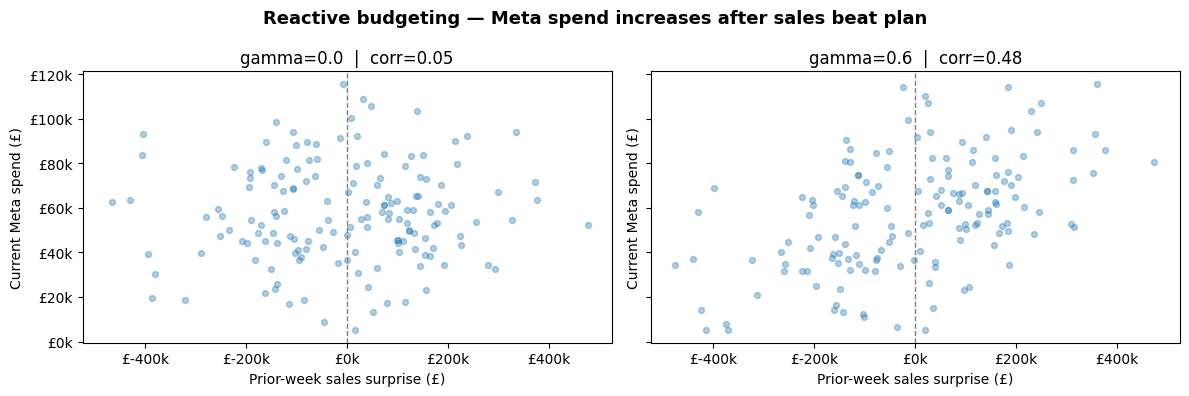

In [16]:
# Visualise the mechanism: current Meta spend vs prior-week sales surprise
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

for ax, (gamma, df, truth) in zip(axes, [(0.0, df0, truth0), (0.6, df6, truth6)]):
    plot_df = df.dropna(subset=['sales_surprise_lag1'])
    ax.scatter(
        plot_df['sales_surprise_lag1'], plot_df['meta'], alpha=0.35, s=18
    )
    ax.axvline(0, color='grey', linestyle='--', linewidth=1)
    ax.set_title(
        f'gamma={gamma}  |  corr={truth["meta_lagged_sales_corr"]:.2f}'
    )
    ax.set_xlabel("Prior-week sales surprise (£)")
    ax.set_ylabel('Current Meta spend (£)')
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}k')
    )
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}k')
    )

fig.suptitle(
    'Reactive budgeting — Meta spend increases after sales beat plan',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

## Section 4 — fit_model() and Single Run

In [17]:
def fit_model(df: pd.DataFrame) -> dict:
    """
    Fit OLS MMM on df.  Controls: trend, sin52, cos52, promo.
    Media: meta, search, tv — no adstock, no saturation.
    The model does NOT include persistent latent demand or the reactive-budget rule.

    Returns dict with ROAS estimates, standard errors, R², and 95% CI bounds.
    """
    X = sm.add_constant(df[['trend', 'sin52', 'cos52', 'promo', 'meta', 'search', 'tv']])
    y = df['revenue']

    res = sm.OLS(y, X).fit()

    channels = ['meta', 'search', 'tv']
    out = {'r2': res.rsquared}
    for ch in channels:
        coef = res.params[ch]
        se   = res.bse[ch]
        out[f'{ch}_roas_est'] = coef
        out[f'{ch}_roas_se']  = se
        out[f'{ch}_roas_lo']  = coef - 1.96 * se
        out[f'{ch}_roas_hi']  = coef + 1.96 * se
    return out

# Single run
result_clean  = fit_model(df0)
result_stress = fit_model(df6)

print('=== Single-run results ===')
header = f'{"Channel":8s}  {"True":>6s}  {"Clean est":>10s}  {"gamma=0.6":>10s}'
print(header)
print('-' * len(header))
for ch in ['meta', 'search', 'tv']:
    true = TRUE_ROAS[ch]
    c_est = result_clean[f'{ch}_roas_est']
    s_est = result_stress[f'{ch}_roas_est']
    print(f'{ch:8s}  {true:>6.2f}  {c_est:>10.3f}  {s_est:>10.3f}')

print(f'\nR² clean={result_clean["r2"]:.3f}   R² gamma=0.6={result_stress["r2"]:.3f}')

=== Single-run results ===
Channel     True   Clean est   gamma=0.6
----------------------------------------
meta        2.00       2.269       3.158
search      5.00       5.360       5.441
tv          1.50       1.587       1.571

R² clean=0.901   R² gamma=0.6=0.907


## Section 5 — run_one_simulation()

In [18]:
def run_one_simulation(gamma: float, seed: int) -> dict:
    """
    Generate data with given gamma and seed, fit OLS, return results dict.
    """
    df, truth = generate_data(gamma=gamma, seed=seed)
    fit = fit_model(df)

    out = {
        'gamma': gamma,
        'seed': seed,
        'r2': fit['r2'],
        'meta_lagged_sales_corr': truth['meta_lagged_sales_corr'],
    }
    for ch in ['meta', 'search', 'tv']:
        true_roas = TRUE_ROAS[ch]
        est  = fit[f'{ch}_roas_est']
        lo   = fit[f'{ch}_roas_lo']
        hi   = fit[f'{ch}_roas_hi']
        out[f'{ch}_roas_est']     = est
        out[f'{ch}_roas_bias']    = est - true_roas
        out[f'{ch}_roas_abserr']  = abs(est - true_roas)
        out[f'{ch}_pct_err']      = (est - true_roas) / true_roas
        out[f'{ch}_large_err']    = int(abs(est - true_roas) / true_roas > 0.50)
        out[f'{ch}_covers_truth'] = int(lo <= true_roas <= hi)
    return out

# Smoke test
test_sim = run_one_simulation(gamma=0.0, seed=42)
print('Smoke test passed. Keys:', list(test_sim.keys()))

Smoke test passed. Keys: ['gamma', 'seed', 'r2', 'meta_lagged_sales_corr', 'meta_roas_est', 'meta_roas_bias', 'meta_roas_abserr', 'meta_pct_err', 'meta_large_err', 'meta_covers_truth', 'search_roas_est', 'search_roas_bias', 'search_roas_abserr', 'search_pct_err', 'search_large_err', 'search_covers_truth', 'tv_roas_est', 'tv_roas_bias', 'tv_roas_abserr', 'tv_pct_err', 'tv_large_err', 'tv_covers_truth']


## Section 6 — Clean-Case Baseline Monte Carlo (N=500)

In [19]:
print(f'Running {N_BASELINE} simulations at gamma=0.0 (clean baseline)...')

baseline_results = []
for i in range(N_BASELINE):
    seed = MASTER_SEED + i
    baseline_results.append(run_one_simulation(gamma=0.0, seed=seed))

baseline_df = pd.DataFrame(baseline_results)

print('\n=== Baseline Summary (gamma=0.0) ===')
for ch in ['meta', 'search', 'tv']:
    mean_est  = baseline_df[f'{ch}_roas_est'].mean()
    mean_bias = baseline_df[f'{ch}_roas_bias'].mean()
    p_large   = baseline_df[f'{ch}_large_err'].mean()
    coverage  = baseline_df[f'{ch}_covers_truth'].mean()
    print(f'  {ch:6s}: mean_est={mean_est:.3f}  bias={mean_bias:+.3f}  '
          f'P(>50% err)={p_large:.3f}  coverage={coverage:.3f}')

print(f'\n  Mean R² = {baseline_df["r2"].mean():.3f}')

Running 500 simulations at gamma=0.0 (clean baseline)...

=== Baseline Summary (gamma=0.0) ===
  meta  : mean_est=2.032  bias=+0.032  P(>50% err)=0.020  coverage=0.942
  search: mean_est=5.020  bias=+0.020  P(>50% err)=0.000  coverage=0.946
  tv    : mean_est=1.496  bias=-0.004  P(>50% err)=0.000  coverage=0.940

  Mean R² = 0.934


## Section 7 — Stress Test Loop (N=300 per gamma level)

In [20]:
print(f'Running stress test: {len(GAMMA_LEVELS)} gamma levels × {N_STRESS} sims each...')

all_results = []
for gamma in GAMMA_LEVELS:
    for i in range(N_STRESS):
        seed = MASTER_SEED + int(gamma * 1_000_000) + i
        all_results.append(run_one_simulation(gamma=gamma, seed=seed))
    print(f'  gamma={gamma:.1f} done ({N_STRESS} sims)')

stress_df = pd.DataFrame(all_results)
print(f'\nTotal simulations: {len(stress_df)}')

Running stress test: 5 gamma levels × 300 sims each...
  gamma=0.0 done (300 sims)
  gamma=0.2 done (300 sims)
  gamma=0.4 done (300 sims)
  gamma=0.6 done (300 sims)
  gamma=0.8 done (300 sims)

Total simulations: 1500


## Section 8 — Summary Table

In [21]:
summary_rows = []
for gamma in GAMMA_LEVELS:
    sub = stress_df[stress_df['gamma'] == gamma]
    row = {
        'gamma': gamma,
        'n_sims': len(sub),
        'mean_r2': sub['r2'].mean(),
        'mean_meta_lagged_sales_corr': sub['meta_lagged_sales_corr'].mean(),
    }
    for ch in ['meta', 'search', 'tv']:
        row[f'{ch}_mean_est']  = sub[f'{ch}_roas_est'].mean()
        row[f'{ch}_mean_bias'] = sub[f'{ch}_roas_bias'].mean()
        row[f'{ch}_p_large']   = sub[f'{ch}_large_err'].mean()
        row[f'{ch}_coverage']  = sub[f'{ch}_covers_truth'].mean()
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print('=== Stress Test Summary ===')
display(summary_df.round(3))

=== Stress Test Summary ===


,gamma,n_sims,mean_r2,mean_meta_lagged_sales_corr,meta_mean_est,meta_mean_bias,meta_p_large,meta_coverage,search_mean_est,search_mean_bias,search_p_large,search_coverage,tv_mean_est,tv_mean_bias,tv_p_large,tv_coverage
0,0.0,300,0.933,0.001,2.028,0.028,0.020,0.943,4.988,-0.012,0.0,0.950,1.497,-0.003,0.000,0.943
1,0.2,300,0.935,0.143,2.249,0.249,0.040,0.897,5.037,0.037,0.0,0.953,1.502,0.002,0.000,0.947
2,0.4,300,0.936,0.286,2.516,0.516,0.167,0.733,4.955,-0.045,0.0,0.957,1.525,0.025,0.000,0.963
3,0.6,300,0.938,0.404,2.680,0.680,0.233,0.550,5.008,0.008,0.0,0.947,1.503,0.003,0.000,0.933
4,0.8,300,0.938,0.522,2.878,0.878,0.353,0.330,5.024,0.024,0.0,0.950,1.515,0.015,0.003,0.940


## Section 9 — Main Chart: Endogeneity Strength vs P(>50% ROAS Error)

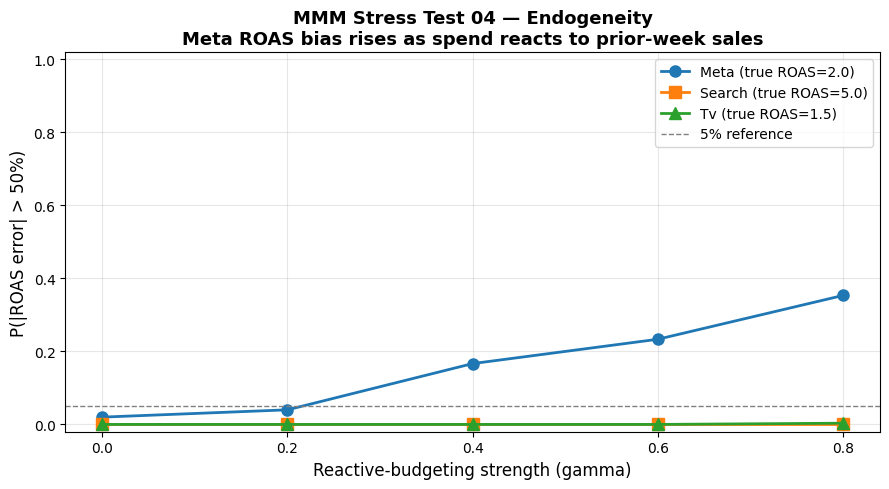

Saved: stress04_main_chart.png


In [22]:
fig, ax = plt.subplots(figsize=(9, 5))

colors = {'meta': '#1f77b4', 'search': '#ff7f0e', 'tv': '#2ca02c'}
markers = {'meta': 'o', 'search': 's', 'tv': '^'}

for ch in ['meta', 'search', 'tv']:
    ax.plot(
        summary_df['gamma'],
        summary_df[f'{ch}_p_large'],
        marker=markers[ch],
        color=colors[ch],
        linewidth=2,
        markersize=8,
        label=f'{ch.capitalize()} (true ROAS={TRUE_ROAS[ch]:.1f})'
    )

ax.axhline(0.05, color='grey', linestyle='--', linewidth=1, label='5% reference')
ax.set_xlabel('Reactive-budgeting strength (gamma)', fontsize=12)
ax.set_ylabel('P(|ROAS error| > 50%)', fontsize=12)
ax.set_title(
    'MMM Stress Test 04 — Endogeneity\n'
    'Meta ROAS bias rises as spend reacts to prior-week sales',
    fontsize=13, fontweight='bold'
)
ax.set_ylim(-0.02, 1.02)
ax.set_xticks(GAMMA_LEVELS)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig('stress04_main_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: stress04_main_chart.png')

## Section 10 — Model Fit (R²) Stays High

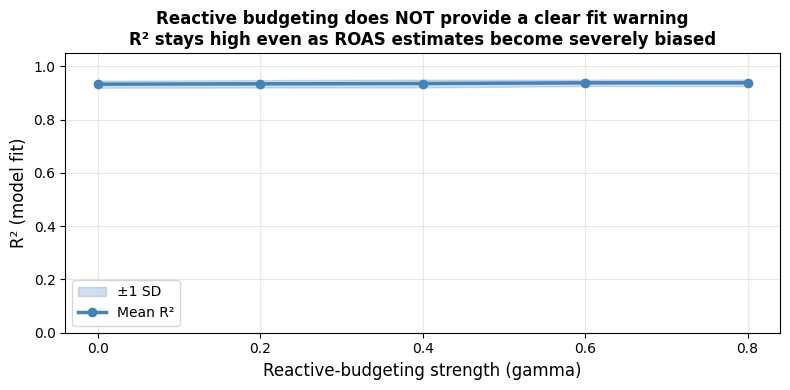

Saved: stress04_r2_chart.png


In [23]:
fig, ax = plt.subplots(figsize=(8, 4))

r2_by_gamma = stress_df.groupby('gamma')['r2'].agg(['mean', 'std']).reset_index()

ax.fill_between(
    r2_by_gamma['gamma'],
    r2_by_gamma['mean'] - r2_by_gamma['std'],
    r2_by_gamma['mean'] + r2_by_gamma['std'],
    alpha=0.25, color='steelblue', label='±1 SD'
)
ax.plot(r2_by_gamma['gamma'], r2_by_gamma['mean'],
        color='steelblue', linewidth=2.5, marker='o', label='Mean R²')

ax.set_xlabel('Reactive-budgeting strength (gamma)', fontsize=12)
ax.set_ylabel('R² (model fit)', fontsize=12)
ax.set_title(
    'Reactive budgeting does NOT provide a clear fit warning\n'
    'R² stays high even as ROAS estimates become severely biased',
    fontsize=12, fontweight='bold'
)
ax.set_ylim(0, 1.05)
ax.set_xticks(GAMMA_LEVELS)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig('stress04_r2_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: stress04_r2_chart.png')

## Section 11 — ROAS Uncertainty Ribbon Chart

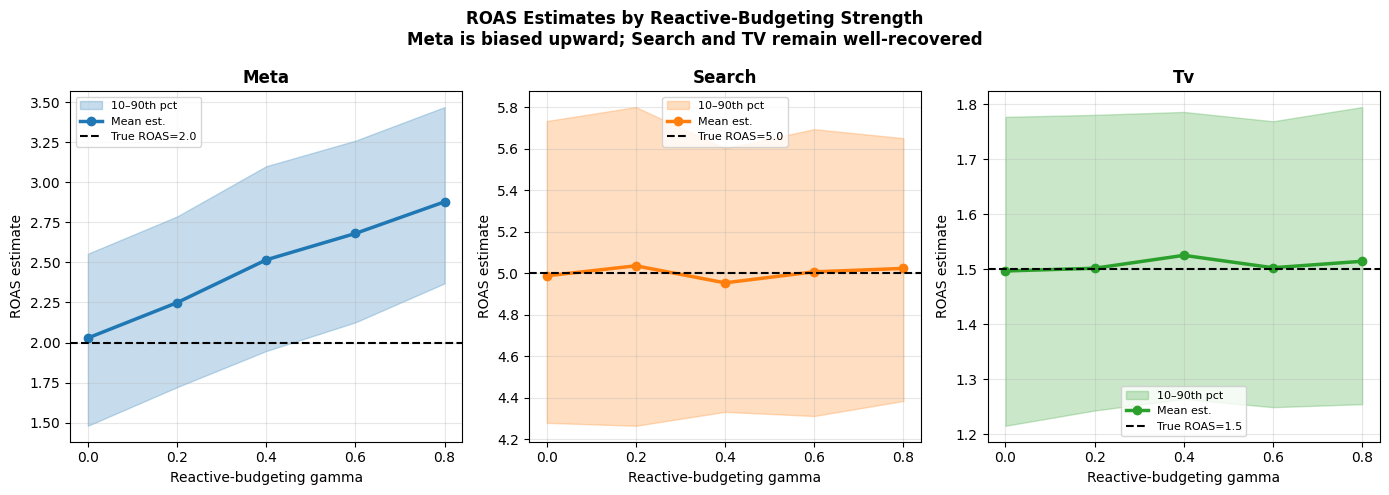

Saved: stress04_roas_ribbon.png


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)

for ax, ch in zip(axes, ['meta', 'search', 'tv']):
    grp = stress_df.groupby('gamma')[f'{ch}_roas_est']
    mean_est = grp.mean()
    lo_est   = grp.quantile(0.10)
    hi_est   = grp.quantile(0.90)

    ax.fill_between(mean_est.index, lo_est.values, hi_est.values,
                    alpha=0.25, color=colors[ch], label='10–90th pct')
    ax.plot(mean_est.index, mean_est.values,
            color=colors[ch], linewidth=2.5, marker='o', label='Mean est.')
    ax.axhline(TRUE_ROAS[ch], color='black', linestyle='--', linewidth=1.5, label=f'True ROAS={TRUE_ROAS[ch]}')

    ax.set_title(f'{ch.capitalize()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Reactive-budgeting gamma')
    ax.set_ylabel('ROAS estimate')
    ax.set_xticks(GAMMA_LEVELS)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('ROAS Estimates by Reactive-Budgeting Strength\nMeta is biased upward; Search and TV remain well-recovered',
             fontsize=12, fontweight='bold')
fig.tight_layout()
plt.savefig('stress04_roas_ribbon.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: stress04_roas_ribbon.png')

## Section 12 — Interpretation

### What we observe

- **The implemented mechanism now matches the question.** At week (t), Meta spend responds to whether sales in week (t-1) exceeded plan. It never uses current or future sales.
- **Meta ROAS becomes upward biased as gamma rises.** In the calibrated Monte Carlo, its mean estimate rises from approximately 2.0 at gamma=0 to approximately 2.9 at gamma=0.8, despite the true causal ROAS remaining 2.0.
- **The feedback requires persistent demand.** An unobserved AR(1) demand shock that raised last week's sales also tends to lift this week's sales. Because Meta spend follows last week's result, it becomes correlated with this week's omitted demand.
- **Search and TV remain comparatively well recovered** because they do not use the reactive-budgeting rule.
- **Model fit still looks healthy.** Predictive fit alone cannot distinguish Meta's causal effect from persistent demand that preceded the spend decision.

### Why this matters

Marketing budgets are often adjusted after recent performance. If strong sales persist, an MMM that omits the underlying demand state can mistake "we spent more because sales were already strong" for "sales became strong because we spent more."

The timing is important: this is lagged feedback, not same-week look-ahead. The simulated planner only sees information that would genuinely have been available when setting the next budget.

### Limitations of this simulation

- The planner reacts to prior sales **relative to an expected-sales plan**, not to raw sales. This prevents normal trend, seasonality, and promotions from being mislabelled as surprises.
- The AR(1) demand process is deliberately simple; real demand persistence can vary over time and may include multiple leading indicators.
- The response rule is linear and clipped at a minimum spend. Real budget changes may use thresholds, pacing constraints, or multi-week averages.
- Only Meta is reactive. In practice, several channels may respond to the same performance signal.
- Lagged sales should not simply be added as an ordinary control without causal thought: prior sales can contain effects from prior media, especially when advertising has carryover.

## Section 13 — Save CSVs

In [25]:
import os
os.makedirs('results', exist_ok=True)

stress_df.to_csv('results/stress04_all_sims.csv', index=False)
summary_df.to_csv('results/stress04_summary.csv', index=False)
baseline_df.to_csv('results/stress04_baseline.csv', index=False)

print('Saved:')
print('  results/stress04_all_sims.csv')
print('  results/stress04_summary.csv')
print('  results/stress04_baseline.csv')
print(f'\nTotal simulations: {len(stress_df)} stress + {len(baseline_df)} baseline')

Saved:
  results/stress04_all_sims.csv
  results/stress04_summary.csv
  results/stress04_baseline.csv

Total simulations: 1500 stress + 500 baseline
